In [1]:
import numpy as np
from pymdp.agent import Agent

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
import imageio
from itertools import product
import random
from IPython.display import Image, display

# reproducibility
random.seed(4225)
np.random.seed(1545)

In [2]:
# BLOCK 1: Build arena mask + mappings (modular arena)
# You can change rows, cols, and corridor params below to create different arenas.

def make_two_rooms_with_corridor(rows=3, left_cols=2, corridor_cols=3, right_cols=2,
                                 corridor_rows=(1),  # tuple/list of row indices that ARE passable in corridor
                                 prefer_total_cols=None):
    """
    Construct a boolean mask for two square rooms (left, right) connected by a corridor.
    Returns mask (rows x total_cols) with True for passable cells and False for blocked.
    corridor_rows: which rows (0-indexed) in the corridor region are allowed to be passable.
                   e.g., (1,2) for two middle rows in a 4-row grid.
    prefer_total_cols: if you need a target total width (e.g. 10), you can supply it and
                       function will try to center corridor; if None, uses left+corridor+right.
    """
    # compute total_cols
    default_total = left_cols + corridor_cols + right_cols
    if prefer_total_cols is None:
        total_cols = default_total
    else:
        total_cols = prefer_total_cols
        # If prefer_total_cols differs from default, we will embed the three regions appropriately
        # We'll place left at col 0, corridor after left, and right at the end so overall fits.
    mask = np.zeros((rows, total_cols), dtype=bool)

    # left room: columns 0 .. left_cols-1 (all rows)
    left_start = 0
    left_end = left_start + left_cols  # exclusive
    mask[:, left_start:left_end] = True

    # corridor: place immediately after left
    corridor_start = left_end
    corridor_end = corridor_start + corridor_cols
    if corridor_end > total_cols:
        raise ValueError("Corridor doesn't fit in prefer_total_cols; increase total width or reduce corridor width.")
    # corridor rows: only allow rows in corridor_rows list (e.g., middle rows)
    for r in corridor_rows:
        mask[r, corridor_start:corridor_end] = True

    # right room: place at the end to make total width sensible
    right_end = total_cols
    right_start = right_end - right_cols
    mask[:, right_start:right_end] = True

    return mask, {"left": (slice(None), slice(left_start, left_end)),
                  "corridor": (slice(None), slice(corridor_start, corridor_end)),
                  "right": (slice(None), slice(right_start, right_end))}

# "T" maze with the perpendicular arm on the right
rows = 4
left_cols = 0
corridor_cols = 3   # corridor width
right_cols = 2
corridor_rows = (1,2)  # allow rows 1 and 2 (middle two rows), top(0) and bottom(3) are blocked in corridor
mask, regions = make_two_rooms_with_corridor(rows=rows, left_cols=left_cols,
                                             corridor_cols=corridor_cols, right_cols=right_cols,
                                             corridor_rows=corridor_rows, prefer_total_cols=None)

print("Arena mask shape:", mask.shape)
print("Passable cells count:", mask.sum())


Arena mask shape: (4, 5)
Passable cells count: 14


In [3]:
# BLOCK 2: Compact mapping from (r,c) -> state index and back for only passable cells


rows, cols = mask.shape
# create list of valid (r,c) and mapping arrays
valid_rc = [(r, c) for r in range(rows) for c in range(cols) if mask[r, c]]
n_states = len(valid_rc)


# observation modalities -> cheese intensity/dist, shelter, agent location
n_cheese_obs = 4                         # intensities 0..3 with higher intensity is closer => can make this modular in the future
n_shelter_obs = 2 # [NOT AT, AT]
n_agent_obs = n_states

actions = ["up", "down", "left", "right", "stay"]
n_actions = len(actions)

# maps: rc -> compact state id (0..n_states-1), and state->(r,c)
rc_to_state = -np.ones((rows, cols), dtype=int)   # -1 for blocked cells
state_to_rc = [None] * n_states
for i, (r, c) in enumerate(valid_rc):
    rc_to_state[r, c] = i
    state_to_rc[i] = (r, c)

def state_idx_to_rc(idx):
    return state_to_rc[int(idx)]

def rc_to_state_idx(r, c):
    return int(rc_to_state[r, c])

print("n_states (valid cells):", n_states)
print("Sample mapping: first 6 states -> rc:", state_to_rc[:6])


n_states (valid cells): 14
Sample mapping: first 6 states -> rc: [(0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3)]


In [4]:
# BLOCK 3: step_from using neighbor adjacency on masked arena
# actions defined as before: 0=up,1=down,2=left,3=right,4=stay

def step_from_state(state_idx, action):
    r, c = state_idx_to_rc(state_idx)
    if action == 0:   # up
        nr, nc = r - 1, c
    elif action == 1: # down
        nr, nc = r + 1, c
    elif action == 2: # left
        nr, nc = r, c - 1
    elif action == 3: # right
        nr, nc = r, c + 1
    elif action == 4: # stay
        nr, nc = r, c
    else:
        raise ValueError("bad action")

    # If target is outside bounds or blocked, stay in place
    if nr < 0 or nr >= rows or nc < 0 or nc >= cols:
        return state_idx
    if not mask[nr, nc]:
        return state_idx
    return rc_to_state_idx(nr, nc)

# Example sanity checks
for i in range(min(6, n_states)):
    r,c = state_idx_to_rc(i)
    print("state", i, "rc", (r,c), "neighbors:", [step_from_state(i,a) for a in range(len(actions))])


state 0 rc (0, 3) neighbors: [0, 5, 0, 1, 0]
state 1 rc (0, 4) neighbors: [1, 6, 0, 1, 1]
state 2 rc (1, 0) neighbors: [2, 7, 2, 3, 2]
state 3 rc (1, 1) neighbors: [3, 8, 2, 4, 3]
state 4 rc (1, 2) neighbors: [4, 9, 3, 5, 4]
state 5 rc (1, 3) neighbors: [0, 10, 4, 6, 5]


In [5]:
# BLOCK 4: Build B (object array) using n_states and the new step_from_state function

n_agent = n_states
n_cheese = n_states
n_shelter = n_states

n_controls_agent = n_actions
n_controls_cheese = 1
n_controls_shelter = 1

# build B_agent: shape (S_next, S_current, n_controls_agent)
B_agent = np.zeros((n_agent, n_agent, n_controls_agent), dtype=float)

for s in range(n_agent):
    for a in range(n_actions):
        ns = step_from_state(s, a)
        # make deterministic-ish with tiny exploration noise
        B_agent[ns, s, a] += 0.99
        # distribute small noise among other reachable neighbors (including stay)
        # find reachable neighbors from s
        neighbors = set(step_from_state(s, aa) for aa in range(n_actions))
        neighbors = sorted(neighbors)
        # distribute 0.01 equally (excluding ns since we already gave 0.99)
        residue = 0.01
        for nb in neighbors:
            if nb == ns:
                continue
            B_agent[nb, s, a] += residue / max(1, (len(neighbors)-1))

# normalize columns for numerical safety
for a in range(n_controls_agent):
    col_sums = B_agent[:, :, a].sum(axis=0)
    # if some column sums slightly != 1 due to rounding, normalize
    for s in range(n_agent):
        if col_sums[s] <= 0:
            B_agent[:, s, a] = 1.0 / n_agent
        else:
            B_agent[:, s, a] /= col_sums[s]

# B for static cheese and shelter (identity)
B_cheese_static = np.zeros((n_cheese, n_cheese, n_controls_cheese))
for s in range(n_cheese):
    B_cheese_static[s, s, 0] = 1.0

B_shelter = np.zeros((n_shelter, n_shelter, n_controls_shelter))
for s in range(n_shelter):
    B_shelter[s, s, 0] = 1.0

# pack into object array B
B = np.empty(3, dtype=object)
B[0] = B_agent
B[1] = B_cheese_static
B[2] = B_shelter

print("Built B with shapes:")
print(" B_agent:", B_agent.shape, "n_states:", n_agent)


Built B with shapes:
 B_agent: (14, 14, 5) n_states: 14


In [6]:
# BLOCK 5: Build A modalities using compact state indices but compute manhattan in rc-space.
# This mirrors your earlier construction but iterates only over valid states.

# helper: compute manhattan distance using rc positions
def manhattan_states(s1, s2):
    r1, c1 = state_idx_to_rc(s1)
    r2, c2 = state_idx_to_rc(s2)
    return abs(r1 - r2) + abs(c1 - c2)

# observation sizes
n_cheese_obs = 6
n_shelter_obs = 5
n_agent_obs = n_agent  # identity proprioception

A_cheese = np.zeros((n_cheese_obs, n_agent, n_cheese, n_shelter))
for a in range(n_agent):
    for t in range(n_cheese):
        for s in range(n_shelter):
            d = manhattan_states(a, t)
            # using same mapping as before but with more flexible arena
            if d == 0:
                A_cheese[5, a, t, s] = 1.0
                # A_cheese[2, a, t, s] = 0.25
            elif d == 1:
                A_cheese[4, a, t, s] = 0.95
                A_cheese[3, a, t, s] = 0.05
            elif d == 2:
                A_cheese[3, a, t, s] = 0.95
                A_cheese[2, a, t, s] = 0.05
            elif d == 3:
                A_cheese[2, a, t, s] = 0.95
                A_cheese[1, a, t, s] = 0.05
            elif d == 4:
                A_cheese[1, a, t, s] = 0.95
                A_cheese[0, a, t, s] = 0.05
            else:
                A_cheese[0, a, t, s] = 1.0
A_cheese /= A_cheese.sum(axis=0, keepdims=True)

# shelter modality (is agent at shelter index?)
A_shelter = np.zeros((n_shelter_obs, n_agent, n_cheese, n_shelter))
for a in range(n_agent):
    for t in range(n_cheese):
        for s in range(n_shelter):
            d = manhattan_states(a, s)
            if d == 0:
                A_shelter[4, a, t, s] = 1.0
            elif d == 1:
                A_shelter[3, a, t, s] = 0.8
                A_shelter[2, a, t, s] = 0.2
            elif d == 2:
                A_shelter[2, a, t, s] = 0.95
                A_shelter[1, a, t, s] = 0.05
            elif d == 3:
                A_shelter[1, a, t, s] = 1.0
            else:
                A_shelter[0, a, t, s] = 1.0
A_shelter /= A_shelter.sum(axis=0, keepdims=True)

# agent proprioception: one-hot on compact index
A_agent = np.zeros((n_agent_obs, n_agent, n_cheese, n_shelter))
for a in range(n_agent):
    A_agent[a, a, :, :] = 1.0
    # small uniform noise for others
    # A_agent[:, a, :, :] += (0.05 / (n_agent_obs - 1))
A_agent /= A_agent.sum(axis=0, keepdims=True)

# pack into object array
A = np.empty(3, dtype=object)
A[0] = A_cheese
A[1] = A_shelter
A[2] = A_agent

print("Built A with shapes:", [A[i].shape for i in range(3)])


Built A with shapes: [(6, 14, 14, 14), (5, 14, 14, 14), (14, 14, 14, 14)]


In [7]:
# BLOCK 6 (REPLACEMENT): D priors — agent & cheese uniform over whole arena; shelter prior = leftmost column

# helper: collect valid states in a column index
def collect_states_in_column(col_idx):
    states = []
    for r in range(rows):
        if 0 <= col_idx < cols and mask[r, col_idx]:
            states.append(rc_to_state_idx(r, col_idx))
    return sorted(states)

# find columns that contain any passable cells
cols_with_passable = np.where(mask.any(axis=0))[0]
if cols_with_passable.size == 0:
    raise RuntimeError("Arena mask has no passable cells.")

leftmost_col = int(cols_with_passable.min())
rightmost_col = int(cols_with_passable.max())

# collect states in leftmost and rightmost columns
leftcol_states = collect_states_in_column(leftmost_col)
rightcol_states = collect_states_in_column(rightmost_col)

print(f"Leftmost column index: {leftmost_col}, states count: {len(leftcol_states)}")
print(f"Rightmost column index: {rightmost_col}, states count: {len(rightcol_states)}")

# --- AGENT & cheese PRIORS: UNIFORM OVER THE ENTIRE ARENA (clueless)
D_agent = np.ones(n_agent, dtype=float) / float(n_agent)
D_cheese = np.ones(n_cheese, dtype=float) / float(n_cheese)

# --- SHELTER PRIOR: uniform over leftmost column
D_shelter = np.zeros(n_shelter, dtype=float)
if len(leftcol_states) > 0:
    D_shelter[leftcol_states] = 1.0 / len(leftcol_states)


# pack into object array for pymdp
D = np.empty(3, dtype=object)
D[0] = D_agent
D[1] = D_cheese
D[2] = D_shelter

print("D shapes:", [D[i].shape for i in range(3)])
print("Agent prior sum:", D_agent.sum(), "cheese prior sum:", D_cheese.sum(),
      "Shelter-prior mass on leftcol:", D_shelter.sum())


Leftmost column index: 0, states count: 2
Rightmost column index: 4, states count: 4
D shapes: [(14,), (14,), (14,)]
Agent prior sum: 0.9999999999999998 cheese prior sum: 0.9999999999999998 Shelter-prior mass on leftcol: 1.0


In [8]:
# BLOCK 7 (REPLACEMENT): observation sampler + renderer that support multi-cell shelter region

def sample_observations(true_agent_pos, true_cheese_pos, true_shelter_pos, A):
    """
    A is object array: A[0] cheese (n_cheese_obs x agent x cheese x shelter),
                       A[1] shelter (n_shelter_obs x agent x cheese x shelter),
                       A[2] agent (n_agent_obs x agent x cheese x shelter)

    true_shelter_pos may be:
      - a single integer index (compact state index) OR
      - an iterable/list/array of integer indices (multiple shelter cells).
    For multiple shelter cells we marginalize the emission over the set uniformly.
    Returns list of ints: [obs_cheese_intensity, obs_shelter_presence, obs_agent_loc]
    """
    # make a list of shelter indices to marginalize over
    if isinstance(true_shelter_pos, (list, tuple, np.ndarray, set)):
        shelter_indices = sorted(list(true_shelter_pos))
        if len(shelter_indices) == 0:
            # fallback to a dummy single 0 if empty (shouldn't happen)
            shelter_indices = [0]
    else:
        shelter_indices = [int(true_shelter_pos)]

    # modality 0: cheese intensity
    # if multiple shelter indices, average the emission probabilities across them (marginalize)
    p_o_cheese = np.zeros(A[0].shape[0], dtype=float)
    for s_idx in shelter_indices:
        p = A[0][:, true_agent_pos, true_cheese_pos, s_idx]
        p_o_cheese += p
    p_o_cheese /= len(shelter_indices)
    p_o_cheese = p_o_cheese / (np.sum(p_o_cheese) + 1e-16)
    obs_cheese = int(np.random.choice(len(p_o_cheese), p=p_o_cheese))

    # modality 1: shelter presence
    p_o_shel = np.zeros(A[1].shape[0], dtype=float)
    for s_idx in shelter_indices:
        p = A[1][:, true_agent_pos, true_cheese_pos, s_idx]
        p_o_shel += p
    p_o_shel /= len(shelter_indices)
    p_o_shel = p_o_shel / (np.sum(p_o_shel) + 1e-16)
    obs_shel = int(np.random.choice(len(p_o_shel), p=p_o_shel))

    # modality 2: agent proprioception (one-hot over agent location)
    p_o_agent = np.zeros(A[2].shape[0], dtype=float)
    for s_idx in shelter_indices:
        p = A[2][:, true_agent_pos, true_cheese_pos, s_idx]
        p_o_agent += p
    p_o_agent /= len(shelter_indices)
    p_o_agent = p_o_agent / (np.sum(p_o_agent) + 1e-16)
    obs_agent = int(np.random.choice(len(p_o_agent), p=p_o_agent))

    return [obs_cheese, obs_shel, obs_agent]


def render_grid_frame_arena(agent_state, cheese_state, shelter_state, visited_states, step,
                            cheese_posterior=None, cell_size=48,
                            high_level_mode=None, current_scale=None, high_posterior=None,
                            high_step=None, upscale=3):
    """
    Render the grid with:
      - high-res internal drawing (upscale) then LANCZOS downsample for smooth shapes
      - no per-cell borders
      - shelters, cheese, visited colors similar to reference
      - agent drawn as a centered circle
      - single black border around the passable arena (or full grid if no passable cells)
      - thin black divider below the top status strip
    """
    from PIL import Image, ImageDraw, ImageFont
    import numpy as np

    # normalize shelter_state
    if isinstance(shelter_state, (list, tuple, np.ndarray, set)):
        shelter_set = set(int(x) for x in shelter_state)
    else:
        shelter_set = {int(shelter_state)}

    # ensure visited is a set and include agent cell as visited
    visited = set(visited_states) if visited_states is not None else set()
    if agent_state is not None:
        try:
            visited.add(int(agent_state))
        except Exception:
            pass

    # upscale / high-res sizes
    S = max(1, int(upscale))
    cell_size_hr = int(cell_size * S)
    W_hr = cols * cell_size_hr
    H_hr = rows * cell_size_hr

    # High-res base image
    img_hr = Image.new('RGB', (W_hr, H_hr), (255, 255, 255))
    draw_hr = ImageDraw.Draw(img_hr)

    # Draw base cells (no borders)
    for r in range(rows):
        for c in range(cols):
            x0 = c * cell_size_hr
            y0 = r * cell_size_hr
            x1 = x0 + cell_size_hr - 1
            y1 = y0 + cell_size_hr - 1

            if not mask[r, c]:
                fill = (0, 0, 0)  # blocked
            else:
                idx = rc_to_state_idx(r, c)
                if (idx in visited) and (idx not in shelter_set) and idx != cheese_state:
                    fill = (220, 220, 220)  # visited
                else:
                    fill = (255, 255, 255)  # free

            draw_hr.rectangle([x0, y0, x1, y1], fill=fill)

    # Heatmap overlay on separate RGBA layer (so we can composite cleanly)
    if cheese_posterior is not None:
        heat_layer = Image.new('RGBA', (W_hr, H_hr), (0, 0, 0, 0))
        draw_heat = ImageDraw.Draw(heat_layer)
        heat = np.zeros((rows, cols))
        for s_idx in range(len(cheese_posterior)):
            rr, cc = state_idx_to_rc(s_idx)
            heat[rr, cc] = float(cheese_posterior[s_idx])
        for r in range(rows):
            for c in range(cols):
                if mask[r, c] and heat[r, c] > 0:
                    a = min(0.9, heat[r, c] * 2.5)
                    alpha = int(a * 200)
                    x0 = c * cell_size_hr
                    y0 = r * cell_size_hr
                    x1 = x0 + cell_size_hr - 1
                    y1 = y0 + cell_size_hr - 1
                    draw_heat.rectangle([x0, y0, x1, y1], fill=(220, 40, 40, alpha))
        img_hr = Image.alpha_composite(img_hr.convert('RGBA'), heat_layer).convert('RGB')
        draw_hr = ImageDraw.Draw(img_hr)

    # Shelters (draw after heat so shelters override heat where present)
    for s_idx in shelter_set:
        r, c = state_idx_to_rc(s_idx)
        x0 = c * cell_size_hr
        y0 = r * cell_size_hr
        x1 = x0 + cell_size_hr - 1
        y1 = y0 + cell_size_hr - 1
        draw_hr.rectangle([x0, y0, x1, y1], fill=(102, 230, 102))

    # cheese (draw after shelters so it's visible)
    if cheese_state is not None:
        r, c = state_idx_to_rc(int(cheese_state))
        x0 = c * cell_size_hr
        y0 = r * cell_size_hr
        x1 = x0 + cell_size_hr - 1
        y1 = y0 + cell_size_hr - 1
        draw_hr.rectangle([x0, y0, x1, y1], fill=(230, 190, 15))
        try:
            fntT = ImageFont.truetype("Inter_18pt-Regular.ttf", 18)
        except Exception:
            fntT = ImageFont.load_default()
        txt = ""
        try:
            bbox = draw_hr.textbbox((0, 0), txt, font=fntT)
            tw = bbox[2] - bbox[0]
            th = bbox[3] - bbox[1]
            tx = x0 + (cell_size_hr - tw) // 2
            ty = y0 + (cell_size_hr - th) // 2
            draw_hr.text((tx, ty), txt, fill=(255, 255, 255), font=fntT)
        except Exception:
            # fallback positioning
            draw_hr.text((x0 + cell_size_hr//3, y0 + cell_size_hr//4), txt, fill=(255,255,255))

    # Agent as a circle (draw last on HR so it is crisp)
    if agent_state is not None:
        r, c = state_idx_to_rc(int(agent_state))
        x0 = c * cell_size_hr
        y0 = r * cell_size_hr
        x1 = x0 + cell_size_hr - 1
        y1 = y0 + cell_size_hr - 1
        pad = max(2, int(cell_size_hr * 0.15))
        ax0, ay0 = x0 + pad, y0 + pad
        ax1, ay1 = x1 - pad, y1 - pad
        draw_hr.ellipse([ax0, ay0, ax1, ay1], fill=(40, 40, 200))
        try:
            fntA = ImageFont.truetype("Inter_18pt-Regular.ttf", 18)
        except Exception:
            fntA = ImageFont.load_default()
        txt = ""
        try:
            bbox = draw_hr.textbbox((0, 0), txt, font=fntA)
            tw = bbox[2] - bbox[0]
            th = bbox[3] - bbox[1]
            tx = x0 + (cell_size_hr - tw) // 2
            ty = y0 + (cell_size_hr - th) // 2
            draw_hr.text((tx, ty), txt, fill=(255, 255, 255), font=fntA)
        except Exception:
            draw_hr.text((x0 + cell_size_hr//3, y0 + cell_size_hr//4), txt, fill=(255,255,255))

    # -------------------------
    # Draw single black outer border around passable arena (or full grid fallback)
    # -------------------------
    # Find passable cells (mask==True). Use argwhere to locate them.
    try:
        passable_positions = np.argwhere(mask == True)
    except Exception:
        passable_positions = np.argwhere(mask)

    if passable_positions.size > 0:
        min_r, min_c = passable_positions.min(axis=0)
        max_r, max_c = passable_positions.max(axis=0)
        x0 = min_c * cell_size_hr
        y0 = min_r * cell_size_hr
        x1 = (max_c + 1) * cell_size_hr - 1
        y1 = (max_r + 1) * cell_size_hr - 1
        draw_hr.rectangle([x0, y0, x1, y1], outline=(0, 0, 0), width=max(1, S))
    else:
        # fallback: outline entire grid
        draw_hr.rectangle([0, 0, cols * cell_size_hr - 1, rows * cell_size_hr - 1],
                          outline=(0, 0, 0), width=max(1, S))

    # -------------------------
    # Top status strip (draw at final resolution)
    # -------------------------
    strip_h = max(46, cell_size // 2)
    final_W = cols * cell_size
    final_H = rows * cell_size + strip_h

    # Downsample HR image to target resolution with high-quality filter
    img_grid = img_hr.resize((cols * cell_size, rows * cell_size), resample=Image.LANCZOS)

    final_img = Image.new('RGB', (final_W, final_H), (255, 255, 255))
    draw_final = ImageDraw.Draw(final_img)

    # font for strip
    try:
        font = ImageFont.truetype("Inter_18pt-Regular.ttf", 18)
    except Exception:
        font = ImageFont.load_default()

    # decide mode color
    mode_is_danger = False
    if high_level_mode is not None:
        try:
            mm = str(high_level_mode).lower()
            mode_is_danger = ('danger' in mm) or ('panic' in mm) or ('alert' in mm)
        except Exception:
            mode_is_danger = False
    elif high_posterior is not None:
        try:
            hp = np.array(high_posterior).ravel()
            p_d = float(hp[1]) if hp.size > 1 else float(hp[0])
            mode_is_danger = (p_d > 0.5)
        except Exception:
            mode_is_danger = False
    else:
        mode_is_danger = False

    strip_color = (180, 30, 30) if mode_is_danger else (30, 160, 50)
    draw_final.rectangle([0, 0, final_W, strip_h], fill=strip_color)

    # thin black divider line below the strip
    draw_final.line([(0, strip_h - 1), (final_W, strip_h - 1)], fill=(0, 0, 0), width=1)

    # Step text
    text_color = (255, 255, 255)
    pad_x = 12
    y_text = (strip_h - 16) // 2
    if high_step is None:
        left_text = f"Step: {int(step)}"
    else:
        left_text = f"Step: {int(step)} ({int(high_step)})"
    draw_final.text((pad_x, y_text), left_text, fill=text_color, font=font)

    # Paste grid under strip and return
    final_img.paste(img_grid, (0, strip_h))


    return np.array(final_img)





In [9]:
def softmax(x):
    ex = np.exp(x - np.max(x))
    return ex / ex.sum()

# cheese_obs outcomes: [none, far, near, at] -> negative increases with closeness
U_cheese = np.array([0.10, 0.20, 0.3, 0.4, 0.8, 2.0])  # more negative -> avoid
C_cheese = np.log(softmax(U_cheese))
# shelter: [] -> prefer being at shelter (positive)
U_shelter = np.array([0.0, 0.1, 0.2, 0.3, 0.5]) # positive for being in shelter
C_shelter = np.log(softmax(U_shelter))
# agent proprio: no utility, keep zeros
U_agent = np.zeros(n_agent_obs)
C_agent = np.log(softmax(U_agent))


# make C arrays of shape (n_outcomes, T) - here broadcast across T
T = policy_len = 1
C = [C_cheese[:,None].repeat(T,axis=1),
     C_shelter[:,None].repeat(T,axis=1),
     C_agent[:,None].repeat(T,axis=1)]

print(f"C (log pref): {C}")

# Convert C (list of arrays shape (n_outcomes, T)) to object array with one entry per modality
C_obj = np.empty(3, dtype=object)
C_obj[0] = C[0]   # cheese modality log-pref (shape (4,T))
C_obj[1] = C[1]   # shelter modality log-pref (shape (2,T))
C_obj[2] = C[2]   # agent proprio (shape (9,T))

C = C_obj

# Convert D (list) to object array (one per hidden factor)
D_obj = np.empty(3, dtype=object)
D_obj[0] = D_agent
D_obj[1] = D_cheese
D_obj[2] = D_shelter

D = D_obj

print("C and D converted to object-arrays for pymdp.")
print("C shapes:", [C[i].shape for i in range(len(C))])
print("D shapes:", [D[i].shape for i in range(len(D))])


C (log pref): [array([[-2.59346801],
       [-2.49346801],
       [-2.39346801],
       [-2.29346801],
       [-1.89346801],
       [-0.69346801]]), array([[-1.84453434],
       [-1.74453434],
       [-1.64453434],
       [-1.54453434],
       [-1.34453434]]), array([[-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733]])]
C and D converted to object-arrays for pymdp.
C shapes: [(6, 1), (5, 1), (14, 1)]
D shapes: [(14,), (14,), (14,)]


In [10]:
# BLOCK C: Generate policies for cheese task
# n_control_factors = number of hidden-state factors = 3 (agent, cheese dummy, shelter dummy)
n_control_factors = 3
num_controls = [n_controls_agent, n_controls_cheese, n_controls_shelter]  # [5,1,1]

def generate_policies(n_actions, n_control_factors, policy_len):
    """
    Returns list of arrays shape (policy_len, n_control_factors),
    where first column is agent actions, others are dummy zeros.
    """
    policies = []
    for seq in product(range(n_actions), repeat=policy_len):
        pol = np.zeros((policy_len, n_control_factors), dtype=int)
        pol[:, 0] = seq   # agent control
        # other factors remain zeros (no control)
        policies.append(pol)
    return policies

policies = generate_policies(n_actions, n_control_factors, policy_len)
n_policies = len(policies)
print(f"Generated {n_policies} policies (h={policy_len}, n_actions={n_actions}).")
print("policy[0] shape:", policies[0].shape)


Generated 5 policies (h=1, n_actions=5).
policy[0] shape: (1, 3)


In [11]:
# BLOCK F: Create the Agent (same args style as mouse-cheese)
# control facets: [n_actions, 1, 1]
agent_obj = Agent(
    A = A,
    B = B,
    C = C,
    D = D,
    policies = policies,
    policy_len = policy_len,
    num_controls = [n_controls_agent, n_controls_cheese, n_controls_shelter],
    control_fac_idx = [0],   # only the agent factor is controllable
    gamma = 2.0,
    alpha = 4.0,
    use_utility = True,
    use_states_info_gain = False
)

print("Agent constructed.")
print("Number of policies:", len(agent_obj.policies))


Agent constructed.
Number of policies: 5


In [12]:
# helper to build low-level C from base utilities + scale factor
U_cheese_base = U_cheese.copy()
U_shelter_base = U_shelter.copy()
U_agent_base = U_agent.copy()

def build_scaled_C(scale):
    """
    Build low-level C object-array given a scale specifier.
    scale may be:
      - scalar (applies to both threat and shelter),
      - tuple/list/ndarray (cheese_scale, shelter_scale),
      - dict with keys 'cheese' and 'shelter'.
    Returns: C_obj (object array) with shapes matching previous code:
      C_obj[0] = cheese modality (n_cheese_obs x policy_len)
      C_obj[1] = shelter modality (n_shelter_obs x policy_len)
      C_obj[2] = agent proprio modality (n_agent_obs x policy_len)
    """
    # interpret scale
    if isinstance(scale, dict):
        cheese_s = float(scale.get('cheese', 1.0))
        shelter_s = float(scale.get('shelter', 1.0))
    elif isinstance(scale, (tuple, list, np.ndarray)):
        cheese_s = float(scale[0])
        shelter_s = float(scale[1])
    else:
        # scalar
        cheese_s = shelter_s = float(scale)

    # scale base utilities (these base vectors should already exist in the namespace)
    U_cheese_scaled = np.array(U_cheese_base, dtype=float) * cheese_s
    U_shelter_scaled = np.array(U_shelter_base, dtype=float) * shelter_s
    U_agent_scaled = np.array(U_agent_base, dtype=float).copy()

    # convert to log-preferences for each modality (softmax -> log)
    # policy_len is expected to be defined in your namespace
    C_th = np.log(softmax(U_cheese_scaled))[:, None].repeat(policy_len, axis=1)
    C_sh = np.log(softmax(U_shelter_scaled))[:, None].repeat(policy_len, axis=1)
    C_ag = np.log(softmax(U_agent_scaled))[:, None].repeat(policy_len, axis=1)

    C_obj_new = np.empty(3, dtype=object)
    C_obj_new[0] = C_th
    C_obj_new[1] = C_sh
    C_obj_new[2] = C_ag
    return C_obj_new


In [13]:
# -------------------- Cleaned simulation loop for CHEESE with teleport-on-collect --------------------
import numpy as np
from copy import deepcopy

# ---- Configuration / stability ----
PROCESS_NOISE = 1e-8     # tiny diffusion to avoid exact zeros
max_steps = 1000

# ---- Convenience references (must match your A/B objects) ----
# A is object-array: A[0] is the smell modality shaped (n_cheese_obs, n_agent, n_cheese, n_shelter)
A_cheese = A[0]
n_cheese_obs, n_agent_obs, n_cheese, n_shelter = A_cheese.shape
# B[1] placeholder - we'll rebuild dynamically each step using build_B_cheese_with_teleport
# But keep this for shape checks if needed
# B_cheese_mat will be created per-step.

# ---- Rendering / recording ----
frames = []
history = {'true_state': [], 'beliefs': [], 'actions': [], 'policy_idx': []}
visited = set()


# ---- Initial true positions (adapt to your chosen initialization) ----
true_agent_pos = rc_to_state_idx(1, 0)
true_cheese_pos = rightcol_states[0]
if len(leftcol_states) > 0:
    true_shelter_pos = np.array(leftcol_states, dtype=int)

current_scale = (5.0, 1.0)
shelter_indices = (list(true_shelter_pos) if isinstance(true_shelter_pos, (list, tuple, np.ndarray)) 
                   else [int(true_shelter_pos)])

visited.add(int(true_agent_pos))

# helper functions
def build_B_cheese_with_teleport(n_states, agent_pos):
    """
    Build B_cheese of shape (n_states, n_states, 1).
    If cheese == agent_pos, next cheese state is uniform over all other states.
    Otherwise cheese stays in place (identity).
    """
    B = np.zeros((n_states, n_states, 1), dtype=float)
    for i in range(n_states):
        col = np.zeros(n_states, dtype=float)
        if i == agent_pos:
            # teleport: uniform to all other passable states (including those that are passable only)
            # we assume all n_states are passable states (from compact mapping)
            col[:] = 1.0 / float(n_states - 1)
            col[i] = 0.0
        else:
            col[i] = 1.0
        B[:, i, 0] = col
    return B

def compute_likelihood_cheese(agent_pos_idx, obs_k, shelter_indices_local):
    """Compute P(o_cheese = obs_k | cheese = i, agent_pos), marginalizing uniformly across shelter cells."""
    lik = np.zeros(n_cheese, dtype=float)
    for i_cheese in range(n_cheese):
        p_vec = np.zeros(n_cheese_obs, dtype=float)
        for sh in shelter_indices_local:
            p_vec += A_cheese[:, agent_pos_idx, i_cheese, sh]
        p_vec /= float(max(1, len(shelter_indices_local)))
        lik[i_cheese] = float(p_vec[obs_k])
    return lik

def predict_cheese_prior_with_B(B_mat, q_prev):
    """Predict q_pred = B_mat @ q_prev, with small noise and normalization."""
    pred = B_mat.dot(q_prev)
    # numerical safety: add tiny uniform noise if it sums to zero or is degenerate
    if np.all(pred == 0) or np.isnan(pred).any():
        pred = np.ones_like(pred) * (1.0 / float(len(pred)))
    pred = pred + PROCESS_NOISE
    pred = pred / (pred.sum() + 1e-16)
    return pred

# Ensure agent_obj has C consistent with your chosen scale (if using scaled utility)
try:
    agent_obj.C = build_scaled_C(current_scale)
except Exception:
    # ignore if current_scale not defined
    pass

# ---- Main loop ----
for t in range(max_steps):
    # 1) sample observation at current true_agent_pos
    obs = sample_observations(int(true_agent_pos), int(true_cheese_pos), true_shelter_pos, A)
    obs_cheese_k = int(obs[0])
    obs_shel_k = int(obs[1])
    obs_agent_k = int(obs[2])

    # 2) run agent's infer_states to update agent/shelter factors if possible (we will overwrite cheese)
    try:
        agent_obj.infer_states(obs)
    except Exception:
        # If infer_states signature differs, ignore (we will set cheese posterior manually below)
        pass

    # get previous cheese posterior (fallback to uniform if unavailable)
    try:
        q_prev_cheese = np.asarray(agent_obj.qs[1], dtype=float).ravel()
    except Exception:
        if len(history['beliefs']) > 0:
            q_prev_cheese = np.asarray(history['beliefs'][-1][1], dtype=float).ravel()
        else:
            q_prev_cheese = np.ones(n_cheese, dtype=float) / float(n_cheese)
    q_prev_cheese = q_prev_cheese / (q_prev_cheese.sum() + 1e-16)

    # 3) build dynamic B_cheese for this timestep (teleport-on-collect behaviour)
    B_cheese = build_B_cheese_with_teleport(n_cheese, int(true_agent_pos))
    B_cheese_mat = B_cheese[:, :, 0]

    # 4) predict and update (manual Bayes) for cheese factor
    q_pred_cheese = predict_cheese_prior_with_B(B_cheese_mat, q_prev_cheese)
    lik_vec = compute_likelihood_cheese(int(true_agent_pos), obs_cheese_k, shelter_indices)
    posterior_unn = lik_vec * q_pred_cheese
    if posterior_unn.sum() <= 0:
        posterior_unn = lik_vec + (1e-12)
    q_post_cheese = posterior_unn / (posterior_unn.sum() + 1e-16)

    # 5) write back posterior into agent_obj.qs (preserving agent & shelter if available)
    try:
        agent_qs = list(agent_obj.qs)
        # guard sizes
        agent_qs[1] = q_post_cheese.copy()
        agent_obj.qs = agent_qs
    except Exception:
        # fallback: create a minimal qs container
        try:
            agent_obj.qs = [None, q_post_cheese.copy(), None]
        except Exception:
            setattr(agent_obj, 'qs', [None, q_post_cheese.copy(), None])

    # 6) extract factors for planning
    try:
        q_agent = np.array(agent_obj.qs[0], dtype=float)
    except Exception:
        q_agent = np.zeros(n_agent, dtype=float)
    q_cheese = np.array(agent_obj.qs[1], dtype=float)
    try:
        q_shelter = np.array(agent_obj.qs[2], dtype=float)
    except Exception:
        # fallback to prior shelter distribution D[2] or zeros
        try:
            q_shelter = np.array(D[2], dtype=float)
        except Exception:
            q_shelter = np.zeros(n_shelter, dtype=float)

    # 7) planning (policy inference)
    try:
        q_pi_agent, neg_efe = agent_obj.infer_policies()
    except Exception:
        try:
            q_pi_agent = np.array(agent_obj.q_pi)
        except Exception:
            q_pi_agent = np.ones(len(policies), dtype=float) / float(len(policies))

    # choose policy stochastically according to q_pi_agent
    chosen_policy_idx = int(np.random.choice(len(policies), p=q_pi_agent))
    chosen_policy = policies[chosen_policy_idx]
    chosen_action = int(chosen_policy[0, 0])

    # 8) apply action in environment (deterministic)
    next_agent_pos = step_from_state(int(true_agent_pos), chosen_action)

    # 9) environment event: if agent reached the cheese, teleport cheese to new random valid cell (not agent)
    if next_agent_pos == int(true_cheese_pos):
        possible_cells = [i for i in range(n_cheese) if i != next_agent_pos]
        # ensure we only choose from passable states (should be true for compact mapping)
        if len(possible_cells) > 0:
            new_cheese_pos = int(np.random.choice(possible_cells))
            print(f"[t={t}] CHEESE TELEPORTED from {state_idx_to_rc(int(true_cheese_pos))} -> {state_idx_to_rc(new_cheese_pos)}")
            true_cheese_pos = new_cheese_pos

    # 10) record synchronous history: belief after seeing obs at true_agent_pos (pre-action) and action chosen
    belief_entry = [np.asarray(q_agent).copy(), np.asarray(q_cheese).copy(), np.asarray(q_shelter).copy()]
    history['beliefs'].append(belief_entry)
    history['true_state'].append(int(true_agent_pos))
    history['actions'].append(int(chosen_action))
    history['policy_idx'].append(int(chosen_policy_idx))

    # 11) advance true agent position and visited set
    true_agent_pos = int(next_agent_pos)
    visited.add(true_agent_pos)

    # 12) render frame (reuse your renderer; pass cheese posterior for visualization)

    frame_img = render_grid_frame_arena(true_agent_pos, true_cheese_pos, true_shelter_pos, visited, t,
                                        # cheese_posterior=q_cheese,
                                        cell_size=100,
                                        high_level_mode=None,
                                        current_scale=None,
                                        high_posterior=None,
                                        high_step=None)
    frames.append(frame_img)


# end main loop
print("Simulation finished: cheese teleport + manual Bayes updates completed.")


[t=17] CHEESE TELEPORTED from (0, 4) -> (2, 2)
[t=30] CHEESE TELEPORTED from (2, 2) -> (1, 3)
[t=67] CHEESE TELEPORTED from (1, 3) -> (0, 3)
[t=109] CHEESE TELEPORTED from (0, 3) -> (1, 3)
[t=163] CHEESE TELEPORTED from (1, 3) -> (0, 4)
[t=216] CHEESE TELEPORTED from (0, 4) -> (2, 1)
[t=239] CHEESE TELEPORTED from (2, 1) -> (0, 4)
[t=257] CHEESE TELEPORTED from (0, 4) -> (2, 2)
[t=333] CHEESE TELEPORTED from (2, 2) -> (0, 4)
[t=411] CHEESE TELEPORTED from (0, 4) -> (1, 2)
[t=454] CHEESE TELEPORTED from (1, 2) -> (0, 4)
[t=545] CHEESE TELEPORTED from (0, 4) -> (2, 3)
[t=596] CHEESE TELEPORTED from (2, 3) -> (2, 4)
[t=598] CHEESE TELEPORTED from (2, 4) -> (3, 3)
[t=602] CHEESE TELEPORTED from (3, 3) -> (1, 0)
[t=699] CHEESE TELEPORTED from (1, 0) -> (0, 4)
[t=848] CHEESE TELEPORTED from (0, 4) -> (1, 1)
[t=891] CHEESE TELEPORTED from (1, 1) -> (3, 4)
[t=952] CHEESE TELEPORTED from (3, 4) -> (1, 3)
Simulation finished: cheese teleport + manual Bayes updates completed.


Saved cheese_sim_4.gif


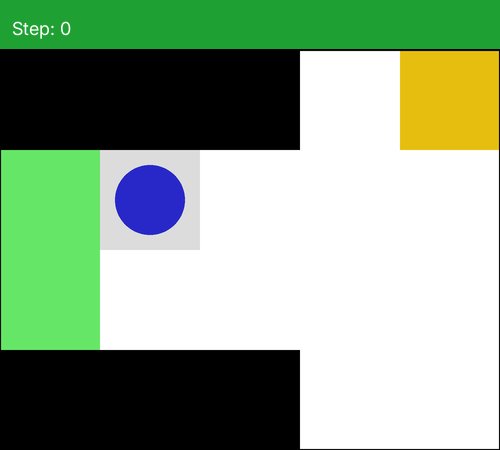

In [14]:
gif_path = "cheese_sim_4.gif"
imageio.mimsave(gif_path, frames, fps=10)
print(f"Saved {gif_path}")
display(Image(gif_path))